Dataset Loaded Successfully!

First 5 Rows:

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9

Dataset Shape:
(200, 4)

Column Names:
Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

Missing Values:

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Cleaned Dataset:

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0

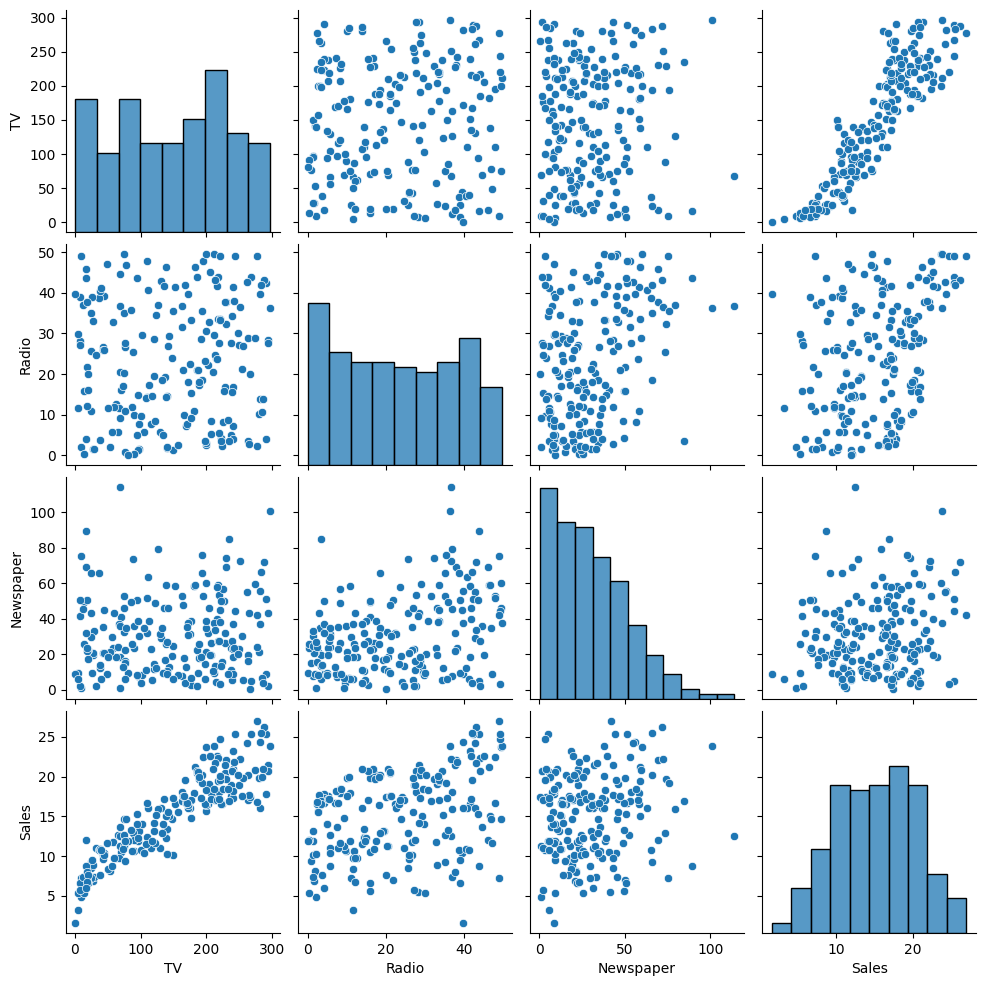

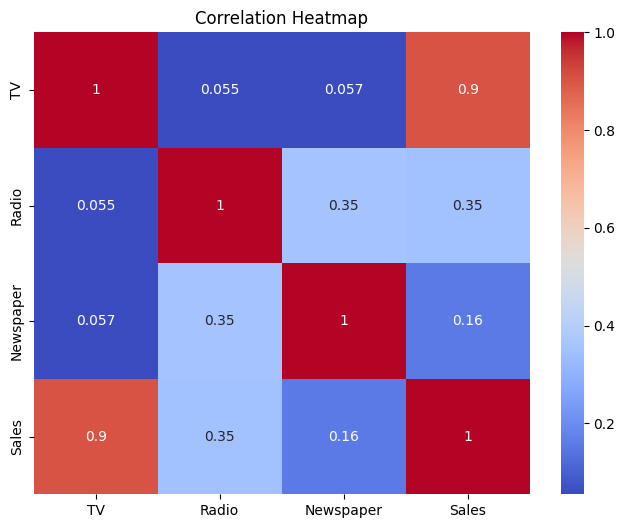

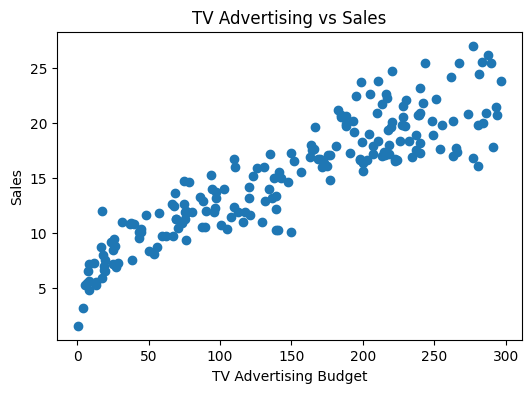

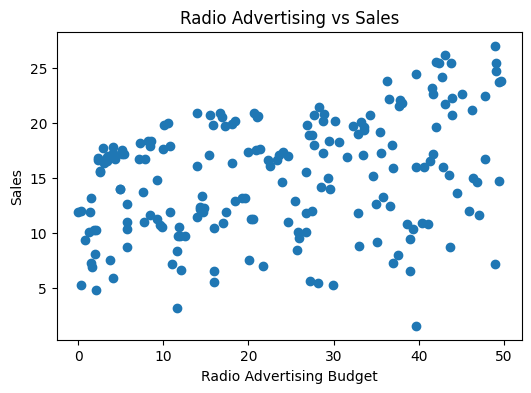

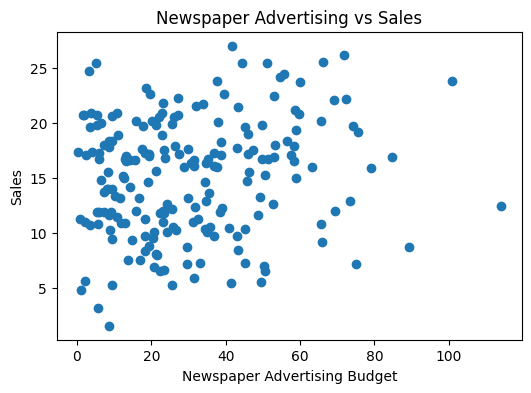


Features:

      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:

0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64

Training Data Shape: (160, 3)
Testing Data Shape: (40, 3)

Model Training Completed!

Predictions Completed!

MODEL PERFORMANCE

Mean Absolute Error: 1.2748262109549338
Mean Squared Error: 2.9077569102710896
Root Mean Squared Error: 1.7052146229349223
R2 Score: 0.9059011844150826


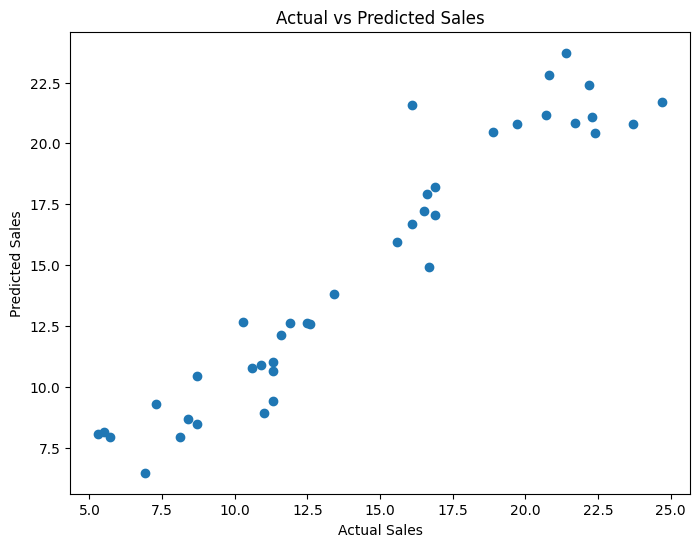


Feature Importance:

     Feature  Coefficient
0         TV     0.054509
1      Radio     0.100945
2  Newspaper     0.004337

Predicted Sales:
21.372540280396883

Model Saved Successfully!

Cleaned Dataset Saved!

Sales Prediction Project Completed Successfully!


In [1]:
# ==========================================
# SALES PREDICTION USING PYTHON
# DATASET: advertising.csv
# ==========================================

# ==========================================
# STEP 1 — IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')


# ==========================================
# STEP 2 — LOAD DATASET
# ==========================================

# Upload advertising.csv in Google Colab first

df = pd.read_csv('advertising.csv')

print("Dataset Loaded Successfully!\n")

print("First 5 Rows:\n")
print(df.head())


# ==========================================
# STEP 3 — DATASET INFORMATION
# ==========================================

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())


# ==========================================
# STEP 4 — REMOVE UNNECESSARY COLUMN
# ==========================================

# Some datasets contain unnamed index column

if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

print("\nCleaned Dataset:\n")
print(df.head())


# ==========================================
# STEP 5 — DATA VISUALIZATION
# ==========================================

# Pairplot

sns.pairplot(df)

plt.show()


# Correlation Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()


# TV vs Sales

plt.figure(figsize=(6,4))

plt.scatter(df['TV'], df['Sales'])

plt.xlabel('TV Advertising Budget')

plt.ylabel('Sales')

plt.title('TV Advertising vs Sales')

plt.show()


# Radio vs Sales

plt.figure(figsize=(6,4))

plt.scatter(df['Radio'], df['Sales'])

plt.xlabel('Radio Advertising Budget')

plt.ylabel('Sales')

plt.title('Radio Advertising vs Sales')

plt.show()


# Newspaper vs Sales

plt.figure(figsize=(6,4))

plt.scatter(df['Newspaper'], df['Sales'])

plt.xlabel('Newspaper Advertising Budget')

plt.ylabel('Sales')

plt.title('Newspaper Advertising vs Sales')

plt.show()


# ==========================================
# STEP 6 — DEFINE FEATURES AND TARGET
# ==========================================

X = df[['TV', 'Radio', 'Newspaper']]

y = df['Sales']

print("\nFeatures:\n")
print(X.head())

print("\nTarget:\n")
print(y.head())


# ==========================================
# STEP 7 — TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)


# ==========================================
# STEP 8 — TRAIN MACHINE LEARNING MODEL
# ==========================================

model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Training Completed!")


# ==========================================
# STEP 9 — MAKE PREDICTIONS
# ==========================================

y_pred = model.predict(X_test)

print("\nPredictions Completed!")


# ==========================================
# STEP 10 — MODEL EVALUATION
# ==========================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\nMODEL PERFORMANCE\n")

print("Mean Absolute Error:", mae)

print("Mean Squared Error:", mse)

print("Root Mean Squared Error:", rmse)

print("R2 Score:", r2)


# ==========================================
# STEP 11 — ACTUAL VS PREDICTED GRAPH
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()


# ==========================================
# STEP 12 — FEATURE IMPORTANCE
# ==========================================

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nFeature Importance:\n")

print(coefficients)


# ==========================================
# STEP 13 — CUSTOM PREDICTION
# ==========================================

# Input Format:
# [TV, Radio, Newspaper]

sample_input = [[230.1, 37.8, 69.2]]

predicted_sales = model.predict(sample_input)

print("\nPredicted Sales:")

print(predicted_sales[0])


# ==========================================
# STEP 14 — SAVE MODEL
# ==========================================

import joblib

joblib.dump(model, 'sales_prediction_model.pkl')

print("\nModel Saved Successfully!")


# ==========================================
# STEP 15 — SAVE CLEANED DATASET (OPTIONAL)
# ==========================================

df.to_csv('cleaned_advertising.csv', index=False)

print("\nCleaned Dataset Saved!")


# ==========================================
# PROJECT COMPLETED
# ==========================================

print("\nSales Prediction Project Completed Successfully!")
